<a href="https://colab.research.google.com/github/NemoStar123/AAI2026/blob/main/Argentic_Ai_Marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
from pprint import pprint

df = pd.read_csv("mock_ad_data.csv")
df.head()


,date,channel,spend,impressions,clicks,conversions
0,2026-03-01,Search,132.26,5902,283,22
1,2026-03-01,Social,120.69,9280,294,16
2,2026-03-01,Display,77.70,12261,146,4
3,2026-03-02,Search,151.52,6277,284,24
4,2026-03-02,Social,136.46,10625,303,14


In [20]:
df["CTR"] = df["clicks"] / df["impressions"]
df["CVR"] = df["conversions"] / df["clicks"]
df["CPA"] = df["spend"] / df["conversions"]

df.head()

,date,channel,spend,impressions,clicks,conversions,CTR,CVR,CPA
0,2026-03-01,Search,132.26,5902,283,22,0.047950,0.077739,6.011818
1,2026-03-01,Social,120.69,9280,294,16,0.031681,0.054422,7.543125
2,2026-03-01,Display,77.70,12261,146,4,0.011908,0.027397,19.425000
3,2026-03-02,Search,151.52,6277,284,24,0.045245,0.084507,6.313333
4,2026-03-02,Social,136.46,10625,303,14,0.028518,0.046205,9.747143


CTR = how often people clicked
CVR = how often clicks turned into conversions
CPA = how much each conversion cost

In [21]:
channels = sorted(df["channel"].unique())
dates = sorted(df["date"].unique())

# Start equal split
budget_alloc = {ch: round(1 / len(channels), 4) for ch in channels}

decision_logs = []
allocation_history = []

for date in dates:
    day_data = df[df["date"] == date].copy()

    # Recompute daily metrics just to be safe
    day_data["CTR"] = day_data["clicks"] / day_data["impressions"]
    day_data["CVR"] = day_data["conversions"] / day_data["clicks"]
    day_data["CPA"] = day_data["spend"] / day_data["conversions"]

    # Pick best channel by CVR
    best_row = day_data.sort_values("CVR", ascending=False).iloc[0]
    best_channel = best_row["channel"]
    best_cvr = best_row["CVR"]

    new_alloc = budget_alloc.copy()
    shift = 0.10  # 10% shift

    # Move budget toward best channel
    new_alloc[best_channel] += shift

    for ch in channels:
        if ch != best_channel:
            new_alloc[ch] -= shift / (len(channels) - 1)

    # Guardrails
    for ch in channels:
        new_alloc[ch] = max(0.20, min(new_alloc[ch], 0.60))

    # Normalize back to 100%
    total = sum(new_alloc.values())
    new_alloc = {k: round(v / total, 4) for k, v in new_alloc.items()}

    # Log rationale
    reason = f"{best_channel} up by 10% due to highest CVR ({best_cvr:.3f}) on {date}"

    allocation_history.append({
        "date": date,
        **new_alloc
    })

    decision_logs.append({
        "date": date,
        "best_channel": best_channel,
        "reason": reason
    })

    budget_alloc = new_alloc

In [22]:
alloc_df = pd.DataFrame(allocation_history)
log_df = pd.DataFrame(decision_logs)

alloc_df.head()


,date,Display,Search,Social
0,2026-03-01,0.2833,0.4333,0.2833
1,2026-03-02,0.2333,0.5334,0.2333
2,2026-03-03,0.2000,0.6000,0.2000
3,2026-03-04,0.2000,0.6000,0.2000
4,2026-03-05,0.2000,0.6000,0.2000


In [23]:
log_df.head(10)

,date,best_channel,reason
0,2026-03-01,Search,Search up by 10% due to highest CVR (0.078) on...
1,2026-03-02,Search,Search up by 10% due to highest CVR (0.085) on...
2,2026-03-03,Search,Search up by 10% due to highest CVR (0.080) on...
3,2026-03-04,Search,Search up by 10% due to highest CVR (0.099) on...
4,2026-03-05,Search,Search up by 10% due to highest CVR (0.081) on...
5,2026-03-06,Search,Search up by 10% due to highest CVR (0.094) on...
6,2026-03-07,Search,Search up by 10% due to highest CVR (0.087) on...
7,2026-03-08,Search,Search up by 10% due to highest CVR (0.081) on...
8,2026-03-09,Search,Search up by 10% due to highest CVR (0.098) on...
9,2026-03-10,Search,Search up by 10% due to highest CVR (0.089) on...


In [24]:
alloc_df.to_csv("budget_allocations.csv", index=False)
log_df.to_csv("decision_log.csv", index=False)

print("Saved budget_allocations.csv and decision_log.csv")

Saved budget_allocations.csv and decision_log.csv


In [25]:
total_spend = df["spend"].sum()
total_impressions = df["impressions"].sum()
total_clicks = df["clicks"].sum()
total_conversions = df["conversions"].sum()

avg_ctr = total_clicks / total_impressions
avg_cvr = total_conversions / total_clicks
avg_cpa = total_spend / total_conversions

print(f"Total Spend: ${total_spend:.2f}")
print(f"Total Impressions: {total_impressions}")
print(f"Total Clicks: {total_clicks}")
print(f"Total Conversions: {total_conversions}")
print(f"Average CTR: {avg_ctr:.4f}")
print(f"Average CVR: {avg_cvr:.4f}")
print(f"Average CPA: ${avg_cpa:.2f}")

Total Spend: $7494.19
Total Impressions: 604958
Total Clicks: 15557
Total Conversions: 947
Average CTR: 0.0257
Average CVR: 0.0609
Average CPA: $7.91


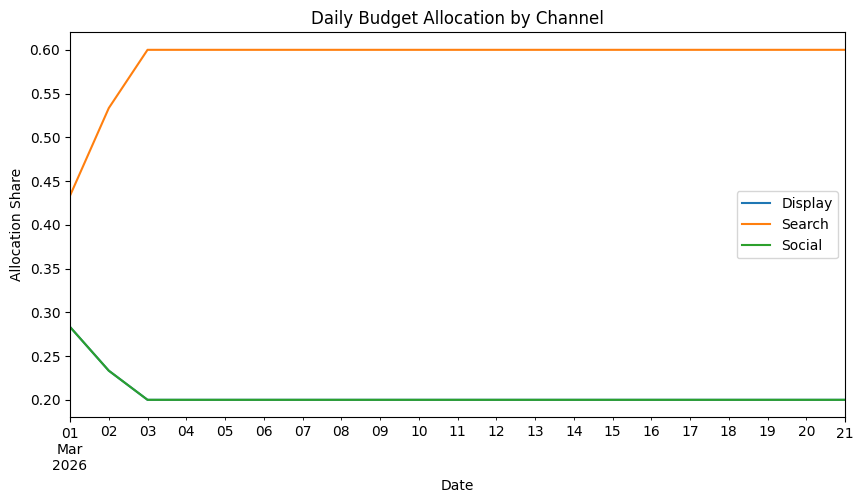

In [26]:
import matplotlib.pyplot as plt

alloc_plot = alloc_df.copy()
alloc_plot["date"] = pd.to_datetime(alloc_plot["date"])
alloc_plot = alloc_plot.set_index("date")

alloc_plot.plot(figsize=(10,5))
plt.title("Daily Budget Allocation by Channel")
plt.ylabel("Allocation Share")
plt.xlabel("Date")
plt.show()

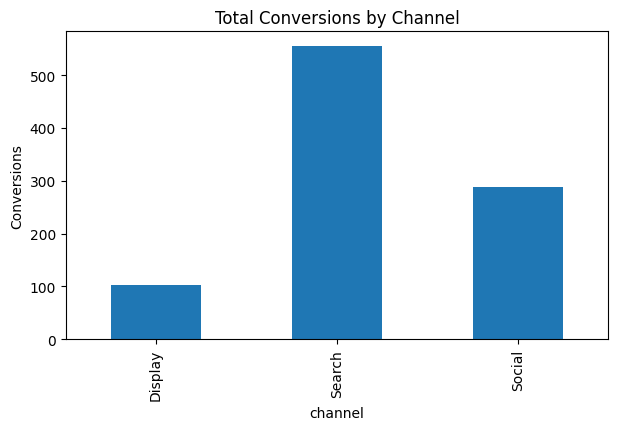

In [27]:
conv_by_channel = df.groupby("channel")["conversions"].sum()
conv_by_channel.plot(kind="bar", figsize=(7,4))
plt.title("Total Conversions by Channel")
plt.ylabel("Conversions")
plt.show()
